In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('/content/OGORBcsv_cleaned.csv')

In [ ]:
df.shape

(119449, 11)

In [ ]:
df.describe()

,Disposition Code
count,119449.000000
mean,17.478656
std,12.907204
min,1.000000
25%,10.000000
50%,17.000000
75%,22.000000
max,68.000000


In [ ]:
df.isnull().sum()

,0
Production Date,0
Land Class,0
Land Category,0
State,0
County,0
FIPS Code,0
Offshore Region,0
Commodity,0
Disposition Code,0
Disposition Description,0


In [ ]:
df.head()

,Production Date,Land Class,Land Category,State,County,FIPS Code,Offshore Region,Commodity,Disposition Code,Disposition Description,Volume
0,01/01/2015,Federal,Offshore,Offshore,Offshore,Offshore,Offshore Alaska,Gas (Mcf),1,Sales-Royalty Due-MEASURED,0
1,01/01/2015,Federal,Offshore,Offshore,Offshore,Offshore,Offshore Gulf,Gas (Mcf),1,Sales-Royalty Due-MEASURED,"14,508,756"
2,01/01/2015,Federal,Offshore,Offshore,Offshore,Offshore,Offshore Pacific,Gas (Mcf),1,Sales-Royalty Due-MEASURED,"1,207,520"
3,01/01/2015,Federal,Offshore,Offshore,Offshore,Offshore,Offshore Gulf,Gas (Mcf),4,Sales-Royalty Due-Not Measured,"487,324"
4,01/01/2015,Federal,Offshore,Offshore,Offshore,Offshore,Offshore Pacific,Gas (Mcf),4,Sales-Royalty Due-Not Measured,"114,808"


In [ ]:
df.tail()

,Production Date,Land Class,Land Category,State,County,FIPS Code,Offshore Region,Commodity,Disposition Code,Disposition Description,Volume
119444,07/01/2017,Federal,Onshore,CA,Kings,6031.0,Onshore,Oil (bbl),27,Water Disposal-Other than Injected/Transferred,0
119445,07/01/2017,Federal,Onshore,CA,Los Angeles,6037.0,Onshore,Oil (bbl),27,Water Disposal-Other than Injected/Transferred,0
119446,07/01/2017,Federal,Onshore,CA,Sacramento,6067.0,Onshore,Oil (bbl),27,Water Disposal-Other than Injected/Transferred,0
119447,07/01/2017,Federal,Onshore,CA,San Joaquin,6077.0,Onshore,Oil (bbl),27,Water Disposal-Other than Injected/Transferred,0
119448,07/01/2017,Federal,Onshore,CA,Solano,6095.0,Onshore,Oil (bbl),27,Water Disposal-Other than Injected/Transfer,NaN


In [ ]:
print(df.columns.tolist())

['Production Date', 'Land Class', 'Land Category', 'State', 'County', 'FIPS Code', 'Offshore Region', 'Commodity', 'Disposition Code', 'Disposition Description', 'Volume']


# **Which state has highest oil/gas production?**

In [ ]:
print(df['State'].unique())
print(df['State'].nunique())

['Offshore' 'AK' 'AL' 'AR' 'CA' 'CO' 'KS' 'KY' 'LA' 'MI' 'MS' 'MT' 'ND'
 'NM' 'NY' 'OH' 'OK' 'PA' 'SD' 'TX' 'UT' 'VA' 'WV' 'WY' 'IL' 'NE' 'NV'
 'ID']
28


In [ ]:
df['Volume'] = df['Volume'].str.replace(',', '').astype(float)

In [ ]:
highest_production =  df.groupby('State')['Volume'].sum().sort_values(ascending=False).head()

In [ ]:
print(highest_production)

State
Offshore    5.769206e+09
WY          3.889518e+09
NM          2.241967e+09
CO          1.693873e+09
UT          6.333037e+08
Name: Volume, dtype: float64


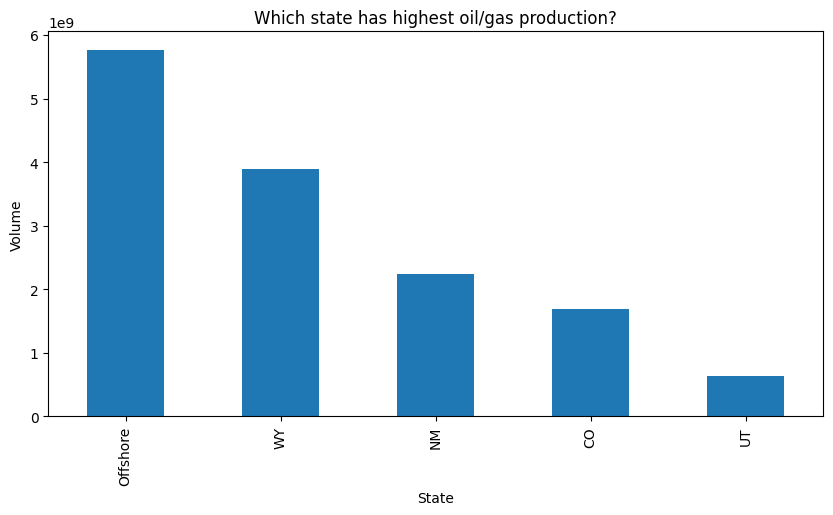

In [ ]:
highest_production.plot(kind='bar',figsize=(10,5),title="Which state has highest oil/gas production?")
plt.xlabel('State')
plt.ylabel('Volume')
plt.show()

# **Which commodity is produced most?**

In [ ]:
commodity = df.groupby('Commodity')['Volume'].sum().sort_values(ascending=False).head()

In [ ]:
print(commodity)

Commodity
Gas (Mcf)    1.268442e+10
Oil (bbl)    2.141609e+09
Name: Volume, dtype: float64


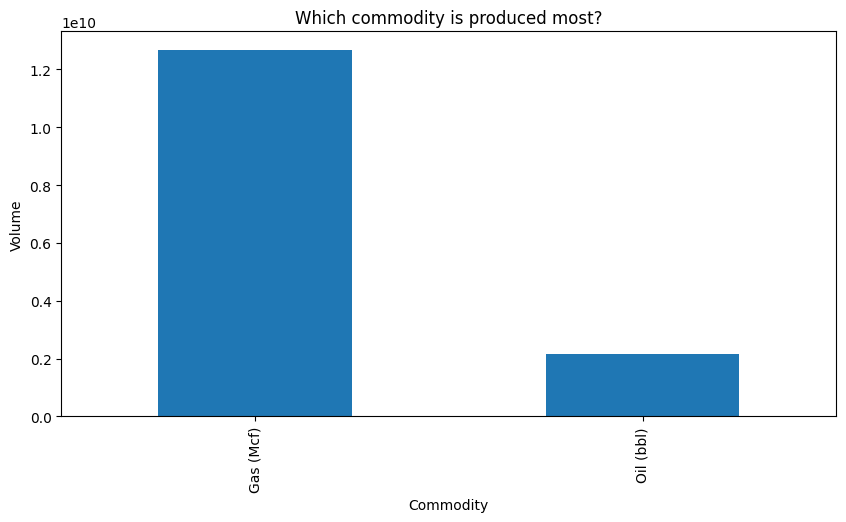

In [ ]:
commodity.plot(kind='bar',figsize=(10,5),title="Which commodity is produced most?")
plt.xlabel('Commodity')
plt.ylabel('Volume')
plt.show()

# **Production trend over years **

In [ ]:
df['Production Date'] = pd.to_datetime(df['Production Date'])

In [ ]:
Trend = df.groupby('Production Date')[['Volume','Commodity']].sum().sort_index()

In [ ]:
print(Trend)

                      Volume  \
Production Date                
2015-01-01       499300687.0   
2015-02-01       451972556.0   
2015-03-01       493122773.0   
2015-04-01       497089327.0   
2015-05-01       505458541.0   
2015-06-01       485052925.0   
2015-07-01       511302768.0   
2015-08-01       515343550.0   
2015-09-01       501552050.0   
2015-10-01       505606562.0   
2015-11-01       483459649.0   
2015-12-01       495946589.0   
2016-01-01       486807106.0   
2016-02-01       455438818.0   
2016-03-01       495551898.0   
2016-04-01       467496527.0   
2016-05-01       481135505.0   
2016-06-01       457321311.0   
2016-07-01       460728576.0   
2016-08-01       468875171.0   
2016-09-01       458488617.0   
2016-10-01       485060456.0   
2016-11-01       468734041.0   
2016-12-01       482861532.0   
2017-01-01       475049584.0   
2017-02-01       430766148.0   
2017-03-01       484334151.0   
2017-04-01       459167367.0   
2017-05-01       471526683.0   
2017-06-

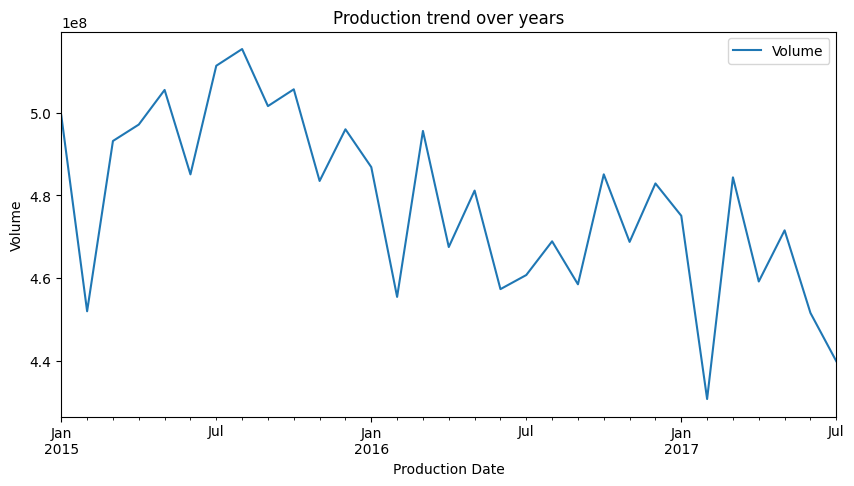

In [ ]:
Trend.plot(kind='line',figsize=(10,5),title="Production trend over years")
plt.xlabel('Production Date')
plt.ylabel('Volume')
plt.show()

# **Onshore vs Offshore production**

In [ ]:
production = df.groupby('Land Class')['Volume'].sum().sort_values(ascending=False)

In [ ]:
print(production)

Land Class
Federal              1.385938e+10
Native American      9.441513e+08
Mixed Exploratory    2.250584e+07
Name: Volume, dtype: float64


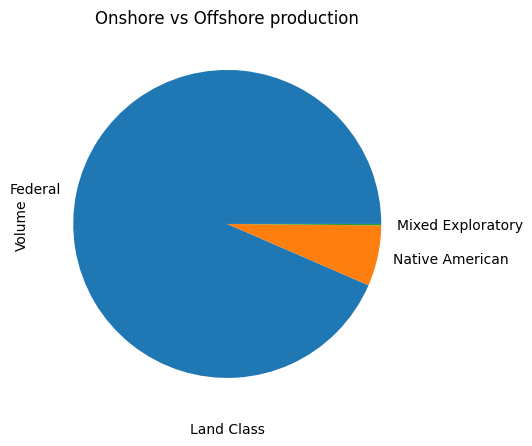

In [ ]:
production.plot(kind='pie',figsize=(10,5),title="Onshore vs Offshore production")
plt.xlabel('Land Class')
plt.ylabel('Volume')
plt.show()

# **Top 10 counties by production**

In [ ]:
top_countries = df.groupby('County')['Volume'].sum().sort_values(ascending=False).head(10)

In [ ]:
print(top_countries)

County
Offshore      5.769206e+09
Sublette      2.452149e+09
San Juan      7.351937e+08
Eddy          5.944395e+08
Rio Arriba    5.104966e+08
Dolores       4.970248e+08
Uintah        4.801914e+08
Garfield      4.388593e+08
Montezuma     3.912014e+08
Lea           3.618008e+08
Name: Volume, dtype: float64


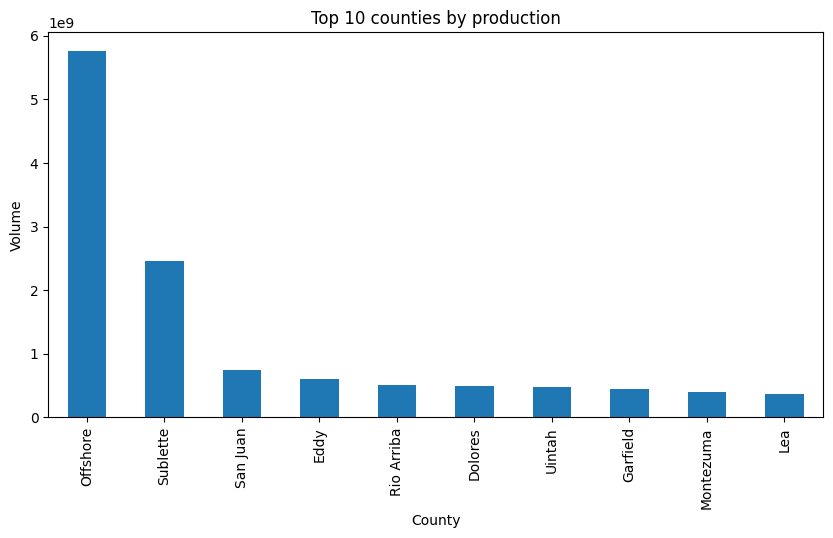

In [ ]:
top_countries.plot(kind='bar',figsize=(10,5),title="Top 10 counties by production")
plt.xlabel('County')
plt.ylabel('Volume')
plt.show()

# **Time Series Forecasting**

In [ ]:
import numpy as np


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
results = pd.DataFrame({'y_test':y_test,'y_pred':y_pred}).dropna()

In [ ]:
df['Date_num'] = pd.to_datetime(df['Production Date']).map(pd.Timestamp.toordinal)

In [ ]:
X = df[['Date_num']]
y = df['Volume']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

In [ ]:
print("R2 Score:", r2_score(results['y_test'], results['y_pred']))
print("MAE:", mean_absolute_error(results['y_test'], results['y_pred']))

R2 Score: -5.2129390456512326e-05
MAE: 228195.50586869873
